In [1]:
import pandas as pd
import importlib
import process_utils as pu
importlib.reload(pu)

<module 'process_utils' from '/home/sam/Downloads/gh/TSCIL-AL/result/process_utils.py'>

In [2]:
# Create dictionary with dataframes for each dataset
tscil_results = {}

# UCI-HAR
tscil_results['HAR'] = pd.DataFrame({
    'Method': ['CIL-ER', 'CIL-ASER'],
    'Avg End Acc': [72.8, 89.1],
    'Avg End Acc error': [19.7, 6.1],
    'Avg End Fgt': [22.1, 13.2],
    'Avg End Fgt error': [37.2, 11.4],
    'Avg Cur Acc': [87.2, 97.8],
    'Avg Cur Acc error': [10.4, 1.9]
})

# UWave
tscil_results['UWAVE'] = pd.DataFrame({
    'Method': ['CIL-ER', 'CIL-ASER'],
    'Avg End Acc': [72.7, 83.2],
    'Avg End Acc error': [2.7, 3.5],
    'Avg End Fgt': [33.6, 20.3],
    'Avg End Fgt error': [3.4, 4.5],
    'Avg Cur Acc': [97.9, 98.4],
    'Avg Cur Acc error': [0.5, 0.4]
})

# DSA
tscil_results['DSA'] = pd.DataFrame({
    'Method': ['CIL-ER', 'CIL-ASER'],
    'Avg End Acc': [79.6, 96.9],
    'Avg End Acc error': [15.6, 2.2],
    'Avg End Fgt': [23.6, 3.7],
    'Avg End Fgt error': [19.2, 2.7],
    'Avg Cur Acc': [89.9, 100.0],
    'Avg Cur Acc error': [9.6, 0.1]
})

# GRABMyo
tscil_results['GRABMYO'] = pd.DataFrame({
    'Method': ['CIL-ER', 'CIL-ASER'],
    'Avg End Acc': [46.5, 55.9],
    'Avg End Acc error': [3.2, 5.1],
    'Avg End Fgt': [35.0, 49.4],
    'Avg End Fgt error': [5.7, 5.0],
    'Avg Cur Acc': [73.7, 95.4],
    'Avg Cur Acc error': [4.7, 1.3]
})

# WISDM
tscil_results['WISDM'] = pd.DataFrame({
    'Method': ['CIL-ER', 'CIL-ASER'],
    'Avg End Acc': [41.7, 51.6],
    'Avg End Acc error': [5.0, 13.7],
    'Avg End Fgt': [27.9, 53.1],
    'Avg End Fgt error': [12.4, 14.3],
    'Avg Cur Acc': [60.7, 95.8],
    'Avg Cur Acc error': [10.2, 2.0]
})

In [3]:
AL_SETUP = {
    'HAR': (3,300),
    'UWAVE' : (3,25),
    'GRABMYO': (6,20),
    'WISDM': (5,40)
}

In [4]:
DATASET = 'HAR'

AL_TOTAL = AL_SETUP[DATASET][0]
AL_BUDGET = AL_SETUP[DATASET][1]

In [5]:
filtered_files = pu.get_filtered_files([DATASET], [AL_TOTAL])
print("Filtered Files:\t", filtered_files)
pu.generate_score_files(filtered_files)

Filtered Files:	 ['har/CoreSet_ER_cycle_3_per_300_har.csv', 'har/Random_ASER_cycle_3_per_300_har.csv', 'har/Uncertainty-entropy_ASER_cycle_3_per_300_har.csv', 'har/CoreSet_ASER_cycle_3_per_300_har.csv', 'har/Uncertainty-margin_ER_cycle_3_per_300_har.csv', 'har/Uncertainty-entropy_ER_cycle_3_per_300_har.csv', 'har/Uncertainty-margin_ASER_cycle_3_per_300_har.csv', 'har/Uncertainty-lc_ASER_cycle_3_per_300_har.csv', 'har/TypiClust_ER_cycle_3_per_300_har.csv', 'har/TypiClust_ASER_cycle_3_per_300_har.csv', 'har/Random_ER_cycle_3_per_300_har.csv', 'har/Uncertainty-lc_ER_cycle_3_per_300_har.csv']


## Uncertainty and Random

In [6]:
uncert_la = pu.aggregate_al_strategies(f'{DATASET.lower()}_scores', ['uncertainty-', 'random'], AL_TOTAL, AL_BUDGET, 'learning_accuracy')
uncert_la.style.apply(pu.highlight_max, axis=1).format(precision=2)

,task,cycle,index,Uncertainty-lc-ASER,Uncertainty-lc-ER,Uncertainty-margin-ASER,Random-ER,Random-ASER,Uncertainty-entropy-ER,Uncertainty-entropy-ASER,Uncertainty-margin-ER
0,0,0,0,77.02,77.02,77.02,77.02,77.02,77.02,77.02,77.02
1,0,1,1,85.31,85.31,85.31,82.98,82.98,85.31,85.31,85.31
2,0,2,2,94.77,94.77,94.77,95.00,95.00,85.12,85.12,94.77
3,1,0,3,77.57,83.52,77.57,79.70,79.53,84.01,78.05,83.52
4,1,1,4,88.42,90.91,87.67,85.64,87.62,88.42,88.06,94.36
5,1,2,5,91.38,93.55,92.95,91.71,94.55,89.28,90.97,95.57
6,2,0,6,87.11,86.40,87.92,86.13,87.89,84.44,89.73,87.24
7,2,1,7,91.51,86.01,91.45,86.02,90.22,87.61,88.10,91.80
8,2,2,8,92.54,87.94,90.88,89.13,91.96,88.21,89.40,92.53


['Random-ER', 'Random-ASER']


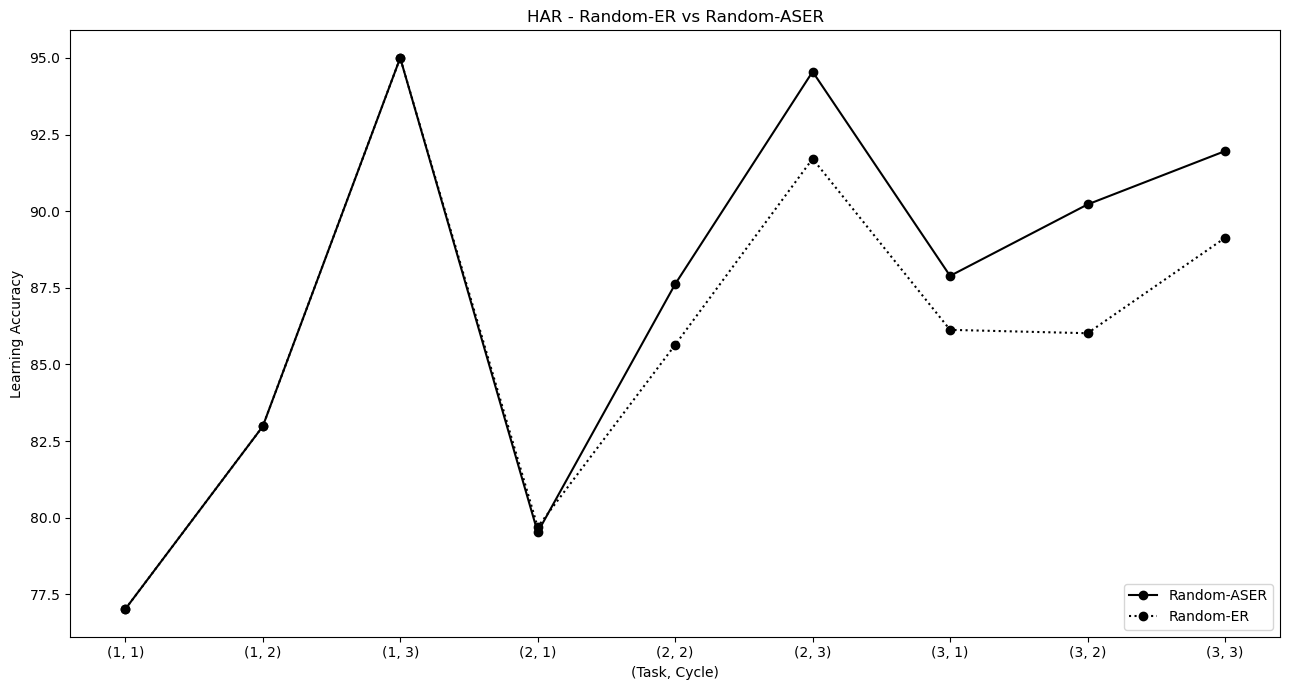

In [7]:
dic = uncert_la[['cycle', 'task', 'Random-ER', 'Random-ASER']]

pu.plot_progress(
    df=dic, 
    loc='lower right',
    title=f"{DATASET} - Random-ER vs Random-ASER",
    X_label="(Task, Cycle)", 
    Y_label="Learning Accuracy")

['Uncertainty-lc-ASER', 'Uncertainty-lc-ER', 'Uncertainty-margin-ASER', 'Random-ER', 'Random-ASER', 'Uncertainty-entropy-ER', 'Uncertainty-entropy-ASER', 'Uncertainty-margin-ER']


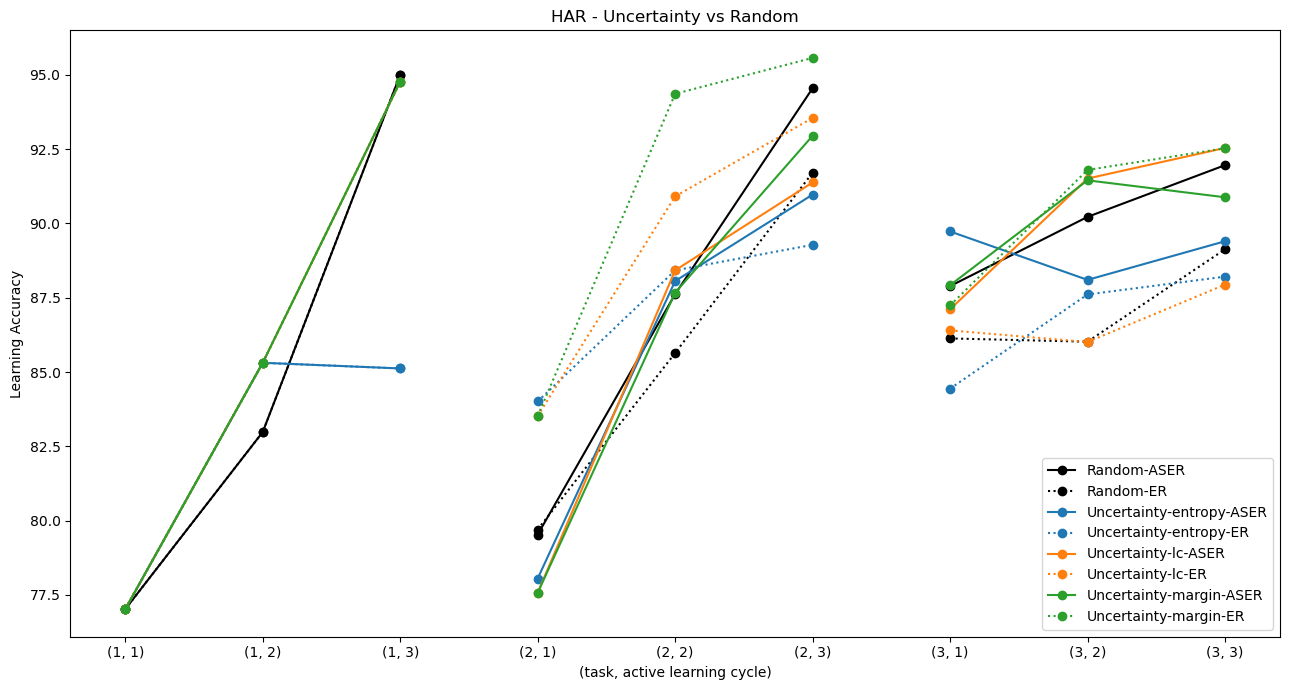

In [8]:
pu.plot_progress(
    df=uncert_la, 
    loc='lower right',
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="(task, active learning cycle)", 
    Y_label="Learning Accuracy",
    break_between_tasks=True
    )

In [9]:
uncert_aa = pu.aggregate_al_strategies(f'{DATASET.lower()}_scores', ['uncertainty-', 'random'], AL_TOTAL, AL_BUDGET, 'average_accuracy')
uncert_aa.style.apply(pu.highlight_max, axis=1).format(precision=2)

,task,cycle,index,Uncertainty-lc-ASER,Uncertainty-lc-ER,Uncertainty-margin-ASER,Random-ER,Random-ASER,Uncertainty-entropy-ER,Uncertainty-entropy-ASER,Uncertainty-margin-ER
0,0,0,0,77.02,77.02,77.02,77.02,77.02,77.02,77.02,77.02
1,0,1,1,85.31,85.31,85.31,82.98,82.98,85.31,85.31,85.31
2,0,2,2,94.77,94.77,94.77,95.00,95.00,85.12,85.12,94.77
3,1,0,3,80.34,84.57,80.34,78.22,78.84,82.56,78.90,84.57
4,1,1,4,80.60,78.78,80.05,77.05,82.84,82.84,80.13,75.11
5,1,2,5,78.85,77.33,73.76,79.29,84.32,75.86,80.08,76.78
6,2,0,6,58.21,67.20,60.94,68.41,64.28,67.19,60.76,68.61
7,2,1,7,55.81,69.69,62.18,69.86,61.89,65.86,60.68,70.99
8,2,2,8,57.46,72.51,62.57,67.83,63.01,69.54,61.10,69.83


['Uncertainty-lc-ASER', 'Uncertainty-lc-ER', 'Uncertainty-margin-ASER', 'Random-ER', 'Random-ASER', 'Uncertainty-entropy-ER', 'Uncertainty-entropy-ASER', 'Uncertainty-margin-ER']


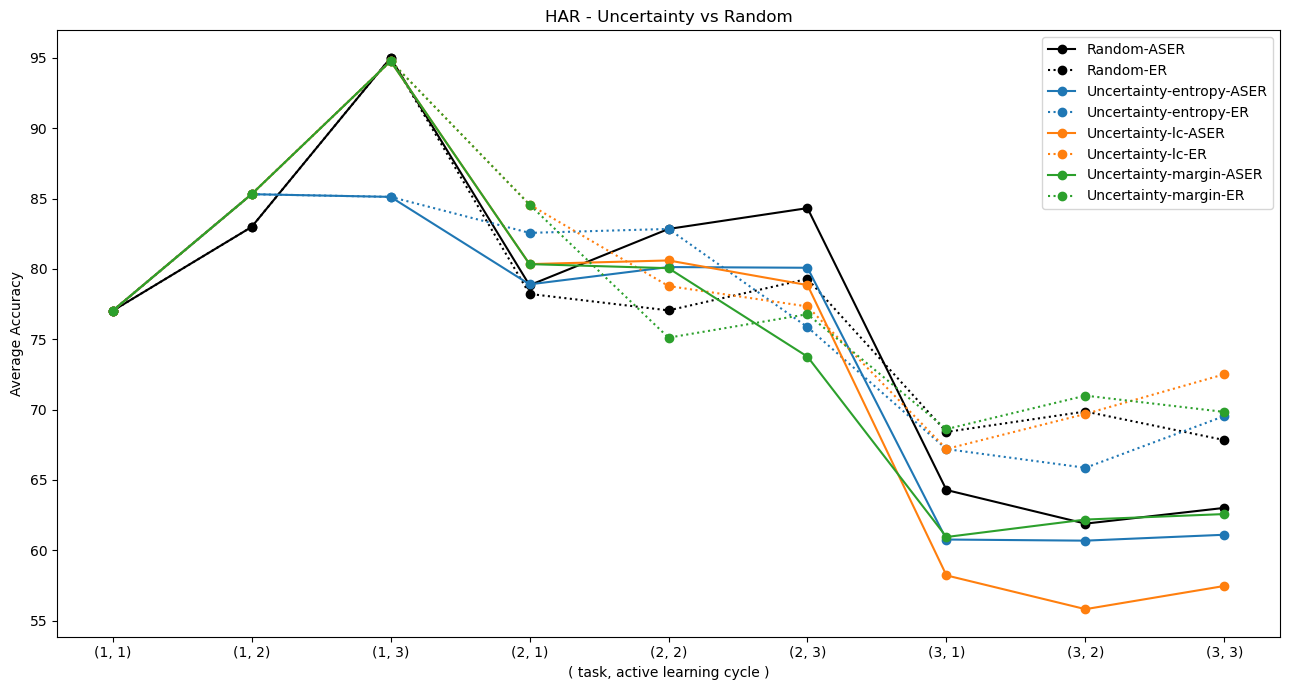

In [10]:
pu.plot_progress(
    df=uncert_aa,
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="( task, active learning cycle )", 
    Y_label="Average Accuracy")

['AA_Random-ASER', 'LA_Random-ER']


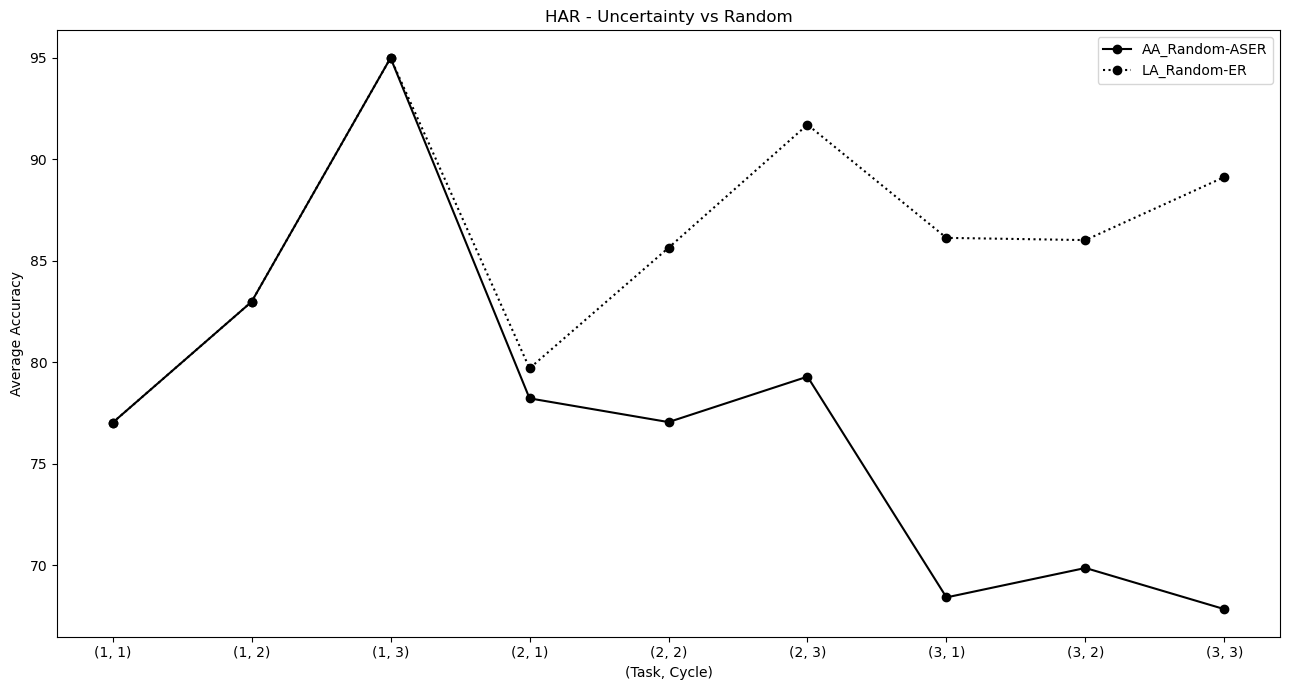

In [11]:
# Create dataframes with prefixes
aa_df = uncert_aa[['task','cycle', 'Random-ER']].copy()
la_df = uncert_la[['Random-ER']].copy()

aa_df.rename(columns={'Random-ER': 'AA_Random-ASER'}, inplace=True)
la_df.rename(columns={'Random-ER': 'LA_Random-ER'}, inplace=True)

df = pd.concat([aa_df, la_df], axis=1)

pu.plot_progress(
    df=df,
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="(Task, Cycle)", 
    Y_label="Average Accuracy")

### Task-based

In [12]:
uncer_aa_task = pu.task_level_filter(uncert_aa) #.drop(['Uncertainty-entropy-ER', 'Uncertainty-entropy-ASER'], axis=1))
uncer_aa_task.style.apply(pu.highlight_max, axis=1).format(precision=2)

,task,cycle,index,Uncertainty-lc-ASER,Uncertainty-lc-ER,Uncertainty-margin-ASER,Random-ER,Random-ASER,Uncertainty-entropy-ER,Uncertainty-entropy-ASER,Uncertainty-margin-ER
0,0,2,2,94.77,94.77,94.77,95.00,95.00,85.12,85.12,94.77
1,1,2,5,78.85,77.33,73.76,79.29,84.32,75.86,80.08,76.78
2,2,2,8,57.46,72.51,62.57,67.83,63.01,69.54,61.10,69.83


['Uncertainty-lc-ASER', 'Uncertainty-lc-ER', 'Uncertainty-margin-ASER', 'Random-ER', 'Random-ASER', 'Uncertainty-entropy-ER', 'Uncertainty-entropy-ASER', 'Uncertainty-margin-ER']


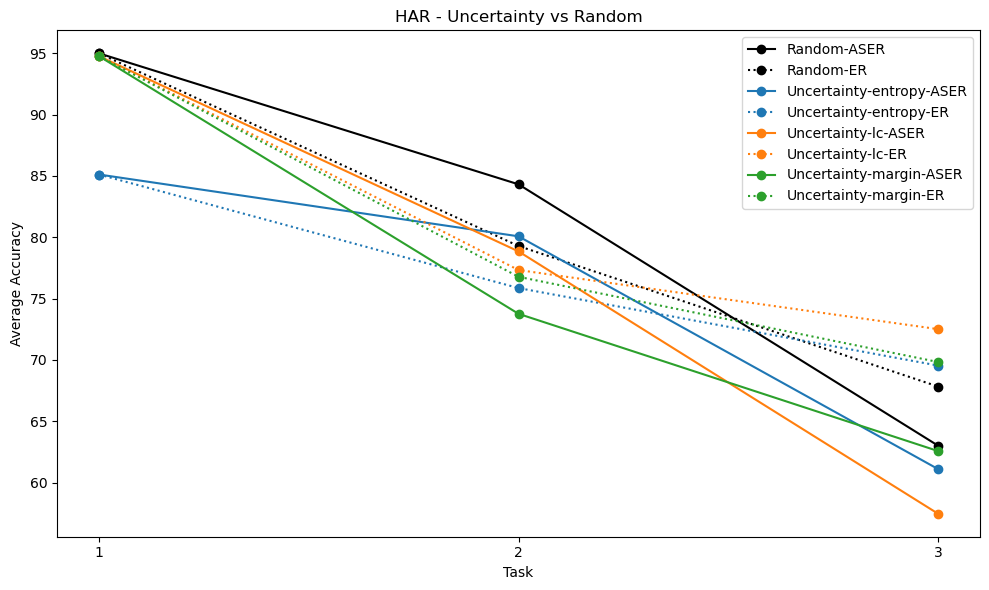

In [13]:
pu.plot_progress(
    df=uncer_aa_task,
    loc = 'upper right',
    figsize=(10, 6),
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="Task", 
    Y_label="Average Accuracy")

In [14]:
uncer_la_task = pu.task_level_filter(uncert_la.drop(['Uncertainty-entropy-ER', 'Uncertainty-entropy-ASER'], axis=1))
uncer_la_task.style.apply(pu.highlight_max, axis=1).format(precision=2)

,task,cycle,index,Uncertainty-lc-ASER,Uncertainty-lc-ER,Uncertainty-margin-ASER,Random-ER,Random-ASER,Uncertainty-margin-ER
0,0,2,2,94.77,94.77,94.77,95.00,95.00,94.77
1,1,2,5,91.38,93.55,92.95,91.71,94.55,95.57
2,2,2,8,92.54,87.94,90.88,89.13,91.96,92.53


['Uncertainty-lc-ASER', 'Uncertainty-lc-ER', 'Uncertainty-margin-ASER', 'Random-ER', 'Random-ASER', 'Uncertainty-margin-ER']


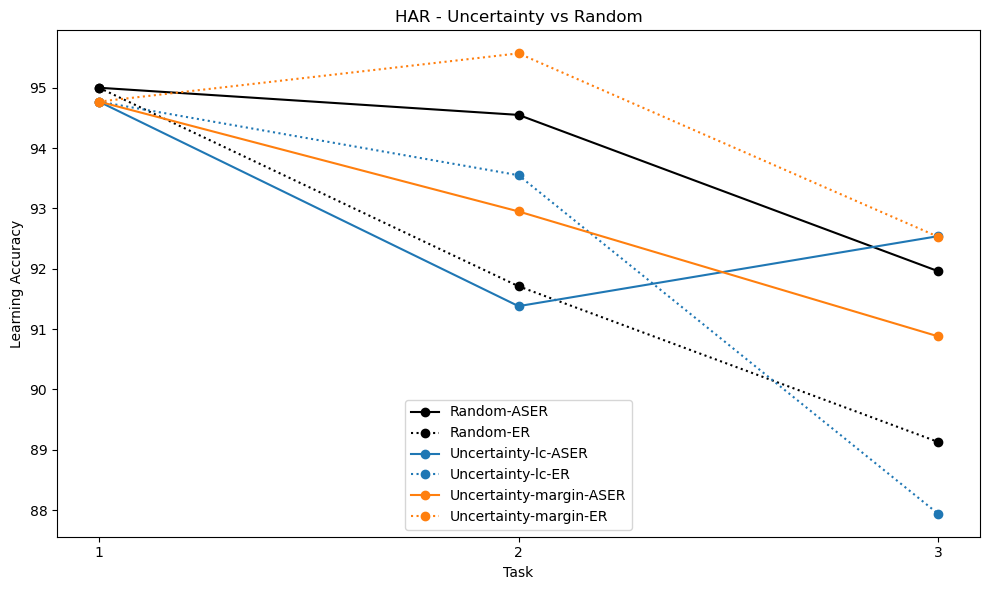

In [15]:
pu.plot_progress(
    df=uncer_la_task,
    loc = 'lower center',
    figsize=(10, 6),
    title=f"{DATASET} - Uncertainty vs Random",
    X_label="Task", 
    Y_label="Learning Accuracy")

In [16]:
pu.add_aser_er_means(uncer_aa_task)
uncer_aa_task[['Random-ASER', 'Random-ER', 'ASER-mean', 'ER-mean']].style.apply(pu.highlight_max, axis=1).format(precision=2)

,Random-ASER,Random-ER,ASER-mean,ER-mean
0,95.00,95.00,91.55,91.55
1,84.32,79.29,77.56,76.66
2,63.01,67.83,60.38,70.63


In [17]:
pu.add_aser_er_means(uncer_la_task)
uncer_la_task[['Random-ASER', 'Random-ER', 'ASER-mean', 'ER-mean']].style.apply(pu.highlight_max, axis=1).format(precision=2)

,Random-ASER,Random-ER,ASER-mean,ER-mean
0,95.00,95.00,94.77,94.77
1,94.55,91.71,92.16,94.56
2,91.96,89.13,91.71,90.23


# Uncertainty Summary

In [18]:
acc_multiple_dataset_multiple_run = pu.get_multiple_al_methods_summary(filtered_files)
results_df = pu.ger_multiple_methods_summary_df(acc_multiple_dataset_multiple_run)
results_df.columns

Index(['Method', 'Avg End Acc', 'Avg End Acc error', 'Avg End Fgt',
       'Avg End Fgt error', 'Avg Cur Acc', 'Avg Cur Acc error', 'Avg Acc',
       'Avg Acc error'],
      dtype='object')

In [19]:
results_df

,Method,Avg End Acc,Avg End Acc error,Avg End Fgt,Avg End Fgt error,Avg Cur Acc,Avg Cur Acc error,Avg Acc,Avg Acc error
0,Uncertainty-margin_ER,69.83,13.98,36.70,26.68,94.29,5.53,"[94.77, 76.78, 69.83]","[7.83, 16.72, 13.98]"
1,Uncertainty-margin_ASER,62.57,6.78,45.80,17.55,92.87,5.35,"[94.77, 73.76, 62.57]","[7.83, 19.85, 6.78]"
2,Uncertainty-lc_ER,72.52,8.00,29.36,19.36,92.09,5.19,"[94.77, 77.33, 72.52]","[7.83, 11.8, 8.0]"
3,Uncertainty-lc_ASER,57.46,9.36,53.15,19.85,92.90,6.41,"[94.77, 78.86, 57.46]","[7.83, 11.93, 9.36]"
4,Uncertainty-entropy_ER,69.54,7.64,28.79,17.61,87.53,6.16,"[85.12, 75.86, 69.54]","[26.34, 10.82, 7.64]"
5,Uncertainty-entropy_ASER,61.10,4.91,43.66,13.96,88.50,8.42,"[85.12, 80.08, 61.1]","[26.34, 6.66, 4.91]"
6,TypiClust_ER,71.71,12.47,35.12,24.34,94.99,6.03,"[93.61, 85.46, 71.71]","[12.15, 18.82, 12.47]"
7,TypiClust_ASER,66.79,11.59,38.53,25.18,92.47,8.43,"[93.61, 81.42, 66.79]","[12.15, 18.58, 11.59]"
8,Random_ER,67.84,4.33,36.30,7.66,91.95,5.19,"[95.0, 79.3, 67.84]","[7.85, 14.13, 4.33]"
9,Random_ASER,63.00,9.12,46.24,22.56,93.83,6.35,"[95.0, 84.32, 63.0]","[7.85, 10.68, 9.12]"


In [25]:
results_dff = results_df[['Method', 'Avg End Acc', 'Avg End Acc error', 'Avg End Fgt',
       'Avg End Fgt error', 'Avg Cur Acc', 'Avg Cur Acc error']]

method_filter = ['Uncertainty-', 'CIL-', 'Random']
results_dff = results_dff[results_dff['Method'].apply(lambda x: any(mf in x for mf in method_filter))]

concat_df = pd.concat([results_dff, tscil_results[DATASET]])
concat_df

,Method,Avg End Acc,Avg End Acc error,Avg End Fgt,Avg End Fgt error,Avg Cur Acc,Avg Cur Acc error
0,Uncertainty-margin_ER,69.83,13.98,36.70,26.68,94.29,5.53
1,Uncertainty-margin_ASER,62.57,6.78,45.80,17.55,92.87,5.35
2,Uncertainty-lc_ER,72.52,8.00,29.36,19.36,92.09,5.19
3,Uncertainty-lc_ASER,57.46,9.36,53.15,19.85,92.90,6.41
4,Uncertainty-entropy_ER,69.54,7.64,28.79,17.61,87.53,6.16
5,Uncertainty-entropy_ASER,61.10,4.91,43.66,13.96,88.50,8.42
8,Random_ER,67.84,4.33,36.30,7.66,91.95,5.19
9,Random_ASER,63.00,9.12,46.24,22.56,93.83,6.35
0,CIL-ER,72.80,19.70,22.10,37.20,87.20,10.40
1,CIL-ASER,89.10,6.10,13.20,11.40,97.80,1.90


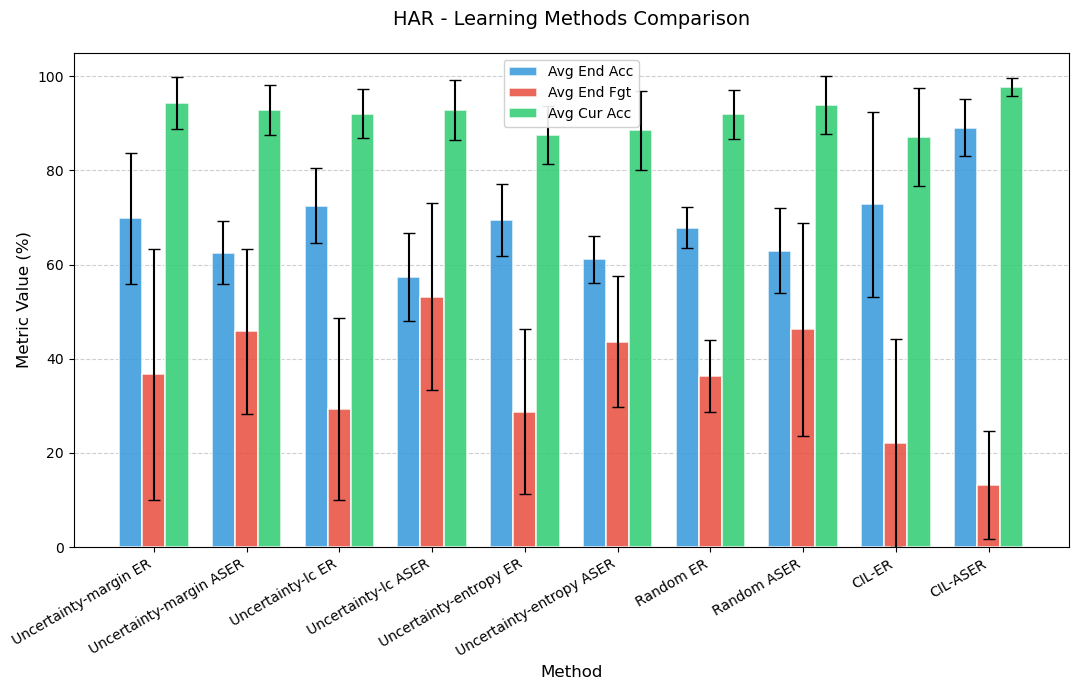

In [26]:
pu.plot_score_values(concat_df, DATASET, 'best')